# Comparação de representações na validação

Este notebook lê exclusivamente o relatório do comparativo de validação. Ele não retreina modelos, não recalcula scores e não acessa a partição de teste.

Condições analisadas: contagens, TF-IDF, embedding semântico e embedding semântico combinado com contagens.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / 'artifacts/detection/hdfs_v1_representation_comparison_validation.json').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

REPORT_PATH = ROOT / 'artifacts/detection/hdfs_v1_representation_comparison_validation.json'
FIGURE_DIR = ROOT / 'artifacts/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titleweight': 'bold',
})
print(f'Projeto: {ROOT}')
print(f'Relatório: {REPORT_PATH}')

Projeto: /Users/jafidelis/Work/estudo/log-analytics
Relatório: /Users/jafidelis/Work/estudo/log-analytics/artifacts/detection/hdfs_v1_representation_comparison_validation.json


In [2]:
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
assert report['acceptance']['accepted'] is True
assert report['protocol']['partition_evaluated'] == 'validation'
assert report['protocol']['test_touched'] is False

rows = []
for result in report['results']:
    metrics = result['validation']
    rows.append({
        'representation': result['representation'],
        'dimensions': result['dimensions'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'pr_auc': result['pr_auc'],
        'tp': metrics['tp'],
        'fp': metrics['fp'],
        'fn': metrics['fn'],
        'threshold': metrics['threshold'],
    })

df = pd.DataFrame(rows)
order = ['counts', 'tfidf', 'semantic', 'semantic_plus_counts']
df['representation'] = pd.Categorical(df['representation'], categories=order, ordered=True)
df = df.sort_values('representation').reset_index(drop=True)
labels = {
    'counts': 'Contagens',
    'tfidf': 'TF-IDF',
    'semantic': 'Embedding',
    'semantic_plus_counts': 'Embedding + contagens',
}
df['label'] = df['representation'].map(labels)
display(df[['label', 'dimensions', 'precision', 'recall', 'f1', 'pr_auc', 'tp', 'fp', 'fn']])

,label,dimensions,precision,recall,f1,pr_auc,tp,fp,fn
0,Contagens,20,0.9468,1.0000,0.9727,0.9879,2526,142,0
1,TF-IDF,159,0.9406,0.9913,0.9653,0.9848,2504,158,22
2,Embedding,384,0.9435,0.9580,0.9507,0.9652,2420,145,106
3,Embedding + contagens,404,0.9874,0.9964,0.9919,0.9946,2517,32,9


## Métricas principais

As barras mostram resultados pontuais da validação. Não representam intervalos de confiança nem significância estatística.

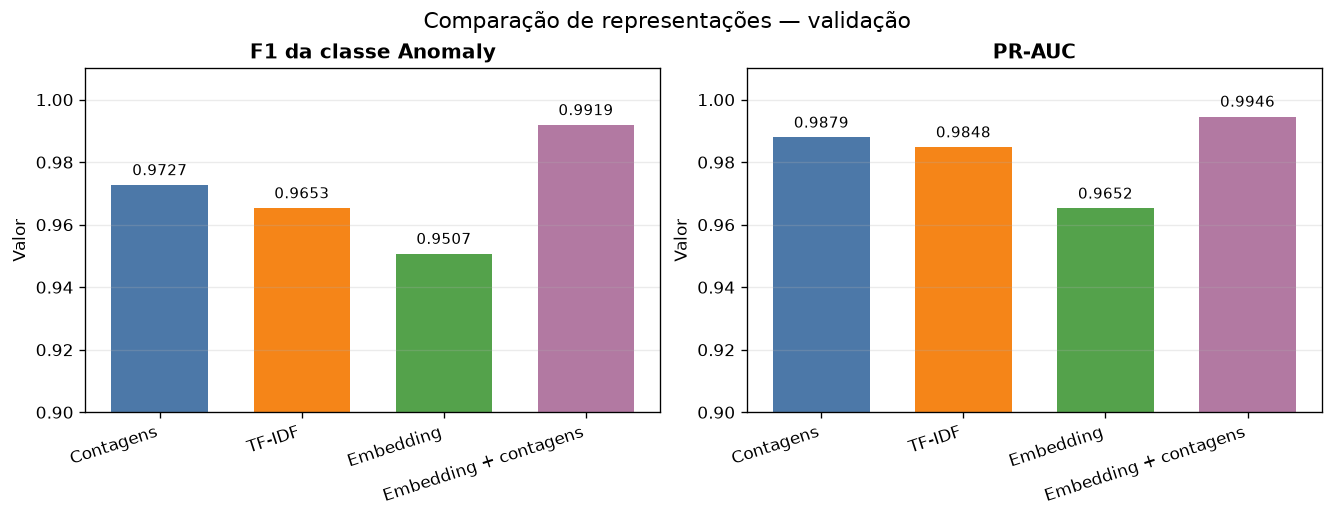

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
colors = ['#4C78A8', '#F58518', '#54A24B', '#B279A2']
x = np.arange(len(df))

for ax, column, title in zip(axes, ['f1', 'pr_auc'], ['F1 da classe Anomaly', 'PR-AUC']):
    bars = ax.bar(x, df[column], color=colors, width=0.68)
    ax.set_xticks(x, df['label'], rotation=18, ha='right')
    ax.set_ylim(0.90, 1.01)
    ax.set_ylabel('Valor')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    for bar, value in zip(bars, df[column]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.002, f'{value:.4f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Comparação de representações — validação', fontsize=13)
fig.savefig(FIGURE_DIR / 'hdfs_v1_representation_f1_pr_auc.png', bbox_inches='tight')
plt.show()

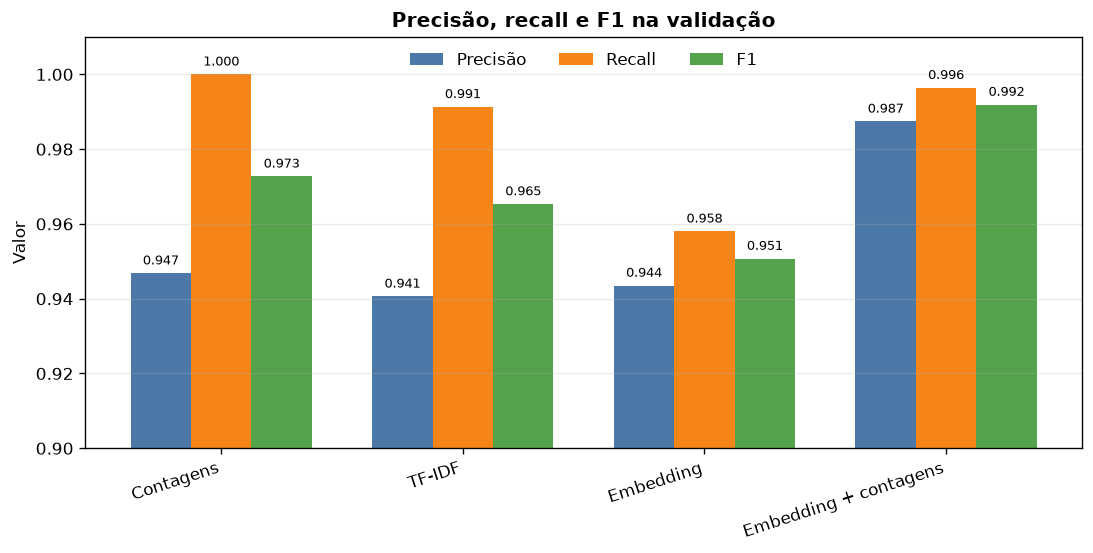

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
width = 0.25
for offset, column, title, color in [
    (-width, 'precision', 'Precisão', '#4C78A8'),
    (0, 'recall', 'Recall', '#F58518'),
    (width, 'f1', 'F1', '#54A24B'),
]:
    bars = ax.bar(x + offset, df[column], width, label=title, color=color)
    for bar, value in zip(bars, df[column]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.0015, f'{value:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x, df['label'], rotation=18, ha='right')
ax.set_ylim(0.90, 1.01)
ax.set_ylabel('Valor')
ax.set_title('Precisão, recall e F1 na validação')
ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.savefig(FIGURE_DIR / 'hdfs_v1_representation_precision_recall_f1.png', bbox_inches='tight')
plt.show()

## Erros de classificação

A combinação semântica + contagens deve ser interpretada como uma representação híbrida. O gráfico mostra a troca entre falsos positivos e falsos negativos, sem sugerir causalidade.

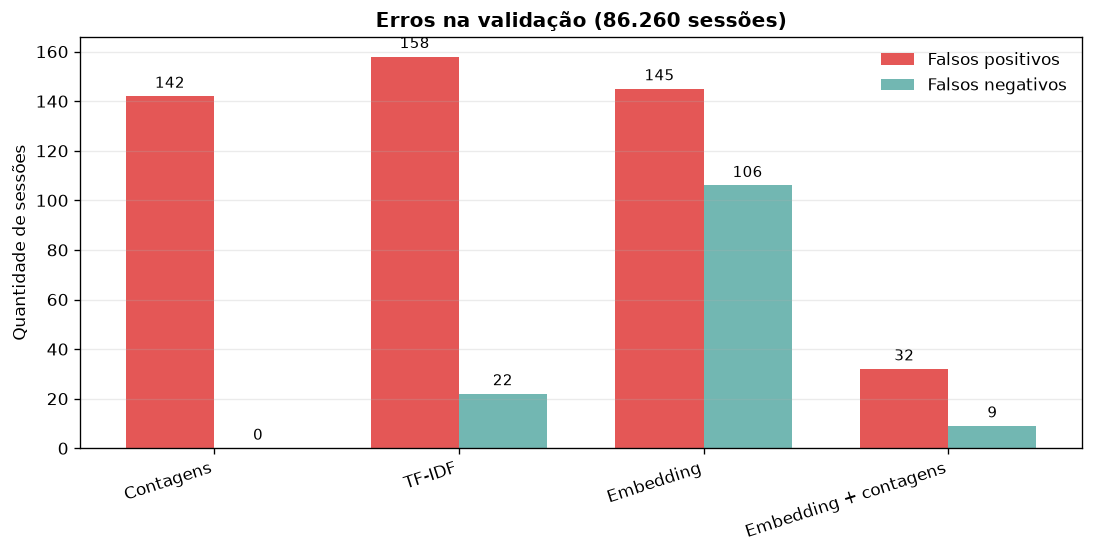

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
width = 0.36
fp_bars = ax.bar(x - width/2, df['fp'], width, label='Falsos positivos', color='#E45756')
fn_bars = ax.bar(x + width/2, df['fn'], width, label='Falsos negativos', color='#72B7B2')
for bars in (fp_bars, fn_bars):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x, df['label'], rotation=18, ha='right')
ax.set_ylabel('Quantidade de sessões')
ax.set_title('Erros na validação (86.260 sessões)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.savefig(FIGURE_DIR / 'hdfs_v1_representation_errors.png', bbox_inches='tight')
plt.show()

In [6]:
counts_f1 = float(df.loc[df['representation'] == 'counts', 'f1'].iloc[0])
semantic_f1 = float(df.loc[df['representation'] == 'semantic', 'f1'].iloc[0])
hybrid_f1 = float(df.loc[df['representation'] == 'semantic_plus_counts', 'f1'].iloc[0])
counts_pr = float(df.loc[df['representation'] == 'counts', 'pr_auc'].iloc[0])
hybrid_pr = float(df.loc[df['representation'] == 'semantic_plus_counts', 'pr_auc'].iloc[0])

print(f'Variação absoluta de F1 do embedding isolado vs. contagens: {semantic_f1 - counts_f1:+.4f}')
print(f'Variação absoluta de F1 do híbrido vs. contagens: {hybrid_f1 - counts_f1:+.4f}')
print(f'Variação absoluta de PR-AUC do híbrido vs. contagens: {hybrid_pr - counts_pr:+.4f}')
print('Interpretação: os números descrevem esta validação; não são estimativas finais de generalização.')

Variação absoluta de F1 do embedding isolado vs. contagens: -0.0220
Variação absoluta de F1 do híbrido vs. contagens: +0.0192
Variação absoluta de PR-AUC do híbrido vs. contagens: +0.0067
Interpretação: os números descrevem esta validação; não são estimativas finais de generalização.


## Exportação para uso posterior

A tabela resumida é exportada junto às figuras para facilitar a preparação das tabelas do Capítulo 5. O teste não é incluído.

In [7]:
table = df[['label', 'dimensions', 'precision', 'recall', 'f1', 'pr_auc', 'tp', 'fp', 'fn', 'threshold']].copy()
table.to_csv(FIGURE_DIR / 'hdfs_v1_representation_comparison_validation.csv', index=False, encoding='utf-8')
print(f'Figuras e tabela gravadas em: {FIGURE_DIR}')

Figuras e tabela gravadas em: /Users/jafidelis/Work/estudo/log-analytics/artifacts/figures
